# Notebook 08 Regime-conditional diversification backtest

## Purpose
Answer the headline question directly with portfolio numbers: **does holding altcoins materially diversify a BTC-heavy portfolio, and does the answer depend on the market regime?**

Notebooks 04/07 forecast BTC direction while this notebook asks whether the diversification thesis the entire project is built on actually holds when you measure it as risk-adjusted returns rather than as a correlation table.

## Method
Three daily-rebalanced portfolios on the aligned 6-asset universe (BTC + 5 altcoins), evaluated over the full data range and broken down by the HMM regime label from notebook 06:

1. **BTC_only** — 100% BTC. The "no diversification" baseline.
2. **Equal_weight** — $1/6$ in each of BTC, ETH, SOL, XRP, BNB, TRX. naive diversification.
3. **BTC_heavy** — 60% BTC + 8% in each altcoin (= 60/40 BTC-vs-altcoin-basket). The realistic "tilt to BTC, sprinkle altcoins" portfolio.

For each portfolio we compute **annualized return**, **annualized volatility**, **Sharpe ratio** (rf=0 for simplicity), **max drawdown**, and the **diversification ratio** $\text{DR} = \frac{\sum_i w_i \sigma_i}{\sigma_p}$. DR > 1 means diversification reduces portfolio vol below the weighted average of constituent vols; DR closer to 1 means the diversification benefit has collapsed.

Each metric is reported over the full sample, and **stratified by HMM regime**. The regime stratification is the whole point. If DR is high in regime 0 and ≈1 in regime 1, the diversification thesis is *regime-dependent*.

## Conventions
- **Returns**: per-asset daily log returns from `crypto_wide_log_returns_aligned.csv` are converted to simple returns ($r_{simple} = e^{r_{log}} - 1$) for cross-asset weighting, then portfolio simple returns are converted back to log for cumulative plotting. Daily rebalancing.
- **Annualization**: mean × 252 for return, std × √252 for vol.
- **No look-ahead**: the regime label at date $t$ is known at end-of-day $t$. We use it only descriptively (slicing returns by regime *after* observing them) — this is not a tradable strategy, it's a diagnostic.
- **Sample**: full aligned range (~2020-05 to 2026-03) by default. The 04/07 test window is too short to see regime variation cleanly (regime 0 had only 36 days in test).

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow

sys.path.append(str(Path.cwd().resolve().parent))
from mlflow_utils import get_or_create_experiment, EXPERIMENT_DIVERSIFICATION
from src.utils.plot_config import COIN_COLORS, apply_plot_style

warnings.filterwarnings("ignore")
apply_plot_style()
mpl.rcParams["figure.facecolor"] = "#F9F7FC"
mpl.rcParams["axes.facecolor"]   = "#FFFFFF"
mpl.rcParams["font.family"]      = "sans-serif"

get_or_create_experiment(EXPERIMENT_DIVERSIFICATION)
mlflow.set_experiment(EXPERIMENT_DIVERSIFICATION)

<Experiment: artifact_location='file:///C:/Users/taula/Github/HSLU/DSPRO2/HSLU_FS25_DSPRO2/mlruns/519867643892831965', creation_time=1777928120839, experiment_id='519867643892831965', last_update_time=1777928120839, lifecycle_stage='active', name='diversification', tags={}>

## Configuration

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PROCESSED_DIR     = PROJECT_ROOT / "data" / "processed"
DATA_MODEL_OUTPUTS_DIR = PROJECT_ROOT / "data" / "model_outputs"

LOG_RETURNS_PATH = DATA_PROCESSED_DIR / "crypto_wide_log_returns_aligned.csv"
HMM_PATH         = DATA_MODEL_OUTPUTS_DIR / "hmm_regime_labels.csv"  # K=2, the canonical 06 output

ASSETS = ["BTC", "ETH", "SOL", "XRP", "BNB", "TRX"]
ALTCOINS = ["ETH", "SOL", "XRP", "BNB", "TRX"]
TRADING_DAYS_PER_YEAR = 252

## Load data

In [3]:
log_returns_df = pd.read_csv(LOG_RETURNS_PATH, parse_dates=["Date"], index_col="Date")[ASSETS]
hmm_df = pd.read_csv(HMM_PATH, parse_dates=["Date"], index_col="Date")[["hmm_regime"]]

# Align on dates that have both a return row and a regime label
data = log_returns_df.join(hmm_df, how="inner").dropna()

print(f"Aligned period: {data.index.min().date()} to {data.index.max().date()}")
print(f"Total days: {len(data)}")
print(f"Regime counts:\n{data['hmm_regime'].value_counts().sort_index()}")

Aligned period: 2020-05-10 to 2026-03-23
Total days: 2144
Regime counts:
hmm_regime
0     674
1    1470
Name: count, dtype: int64


## Define portfolios

Each portfolio is just a weight vector. Daily rebalancing is implied by computing the portfolio's daily return as a weighted sum of constituent simple returns.

In [4]:
PORTFOLIOS = {
    "BTC_only":      {"BTC": 1.00, "ETH": 0.00, "SOL": 0.00, "XRP": 0.00, "BNB": 0.00, "TRX": 0.00},
    "Equal_weight":  {a: 1.0 / len(ASSETS) for a in ASSETS},
    "BTC_heavy":     {"BTC": 0.60, **{a: 0.40 / len(ALTCOINS) for a in ALTCOINS}},
}

weights_df = pd.DataFrame(PORTFOLIOS).T[ASSETS]
print("Portfolio weights:")
print(weights_df.round(3))
print(f"\nRow sums (sanity check, should all be 1.0): {weights_df.sum(axis=1).tolist()}")

Portfolio weights:
                BTC    ETH    SOL    XRP    BNB    TRX
BTC_only      1.000  0.000  0.000  0.000  0.000  0.000
Equal_weight  0.167  0.167  0.167  0.167  0.167  0.167
BTC_heavy     0.600  0.080  0.080  0.080  0.080  0.080

Row sums (sanity check, should all be 1.0): [1.0, 0.9999999999999999, 0.9999999999999998]


## Compute daily portfolio returns

Per-asset log returns are converted to simple returns for weighted aggregation, then the portfolio simple return is converted back to log return for plotting and cumulation.

In [5]:
# Convert per-asset log returns to simple returns
simple_returns = np.exp(data[ASSETS]) - 1.0

# Daily portfolio simple return = weights · asset simple returns
portfolio_simple = pd.DataFrame(
    {name: simple_returns @ pd.Series(w) for name, w in PORTFOLIOS.items()},
    index=simple_returns.index,
)

# Back to log returns for additive time aggregation
portfolio_log = np.log1p(portfolio_simple)
portfolio_log["regime"] = data["hmm_regime"].astype(int)

print("Portfolio log returns head:")
portfolio_log.head().round(5)

Portfolio log returns head:


,BTC_only,Equal_weight,BTC_heavy,regime
Date,,,,
2020-05-10,-0.09134,-0.10704,-0.09884,0
2020-05-11,-0.01782,-0.02095,-0.01932,0
2020-05-12,0.02329,0.03059,0.02680,0
2020-05-13,0.05152,0.03319,0.04276,0
2020-05-14,0.04881,0.02335,0.03667,1


## Performance metrics

In [6]:
def annualized_return(log_returns: pd.Series) -> float:
    return float(log_returns.mean() * TRADING_DAYS_PER_YEAR)

def annualized_vol(log_returns: pd.Series) -> float:
    return float(log_returns.std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR))

def sharpe_ratio(log_returns: pd.Series) -> float:
    vol = annualized_vol(log_returns)
    return float(annualized_return(log_returns) / vol) if vol > 0 else 0.0

def max_drawdown(log_returns: pd.Series) -> float:
    """Max drawdown of cumulative log return path."""
    cum = log_returns.cumsum()
    running_peak = cum.cummax()
    return float((cum - running_peak).min())

def diversification_ratio(simple_returns_assets: pd.DataFrame, weights: pd.Series) -> float:
    """DR = sum_i (w_i * sigma_i) / sigma_p.

    Computed on simple returns since portfolio variance is additive in simple-return space.
    DR > 1 means diversification reduces portfolio vol below the weighted-average constituent vol.
    """
    sigma_assets = simple_returns_assets.std(ddof=1)
    weighted_avg_vol = float((weights * sigma_assets).sum())
    portfolio_returns = simple_returns_assets @ weights
    sigma_portfolio = float(portfolio_returns.std(ddof=1))
    return weighted_avg_vol / sigma_portfolio if sigma_portfolio > 0 else float("nan")

def summarize(portfolio_log_returns: pd.Series, asset_simple_returns: pd.DataFrame, weights: pd.Series) -> dict:
    return {
        "n_days": len(portfolio_log_returns),
        "ann_return": annualized_return(portfolio_log_returns),
        "ann_vol":    annualized_vol(portfolio_log_returns),
        "sharpe":     sharpe_ratio(portfolio_log_returns),
        "max_drawdown": max_drawdown(portfolio_log_returns),
        "diversification_ratio": diversification_ratio(asset_simple_returns, weights),
    }

## Full-sample portfolio comparison

In [7]:
full_summary = {}
for name in PORTFOLIOS:
    weights = pd.Series(PORTFOLIOS[name])[ASSETS]
    full_summary[name] = summarize(portfolio_log[name], simple_returns, weights)

full_summary_df = pd.DataFrame(full_summary).T[
    ["n_days", "ann_return", "ann_vol", "sharpe", "max_drawdown", "diversification_ratio"]
]
print("Full sample (descriptive, no look-ahead claims):")
full_summary_df.round(4)

Full sample (descriptive, no look-ahead claims):


,n_days,ann_return,ann_vol,sharpe,max_drawdown,diversification_ratio
BTC_only,2144.0,0.2332,0.4826,0.4832,-1.4539,1.0000
Equal_weight,2144.0,0.4552,0.5726,0.7950,-1.4041,1.2846
BTC_heavy,2144.0,0.3530,0.5021,0.7030,-1.4120,1.2042


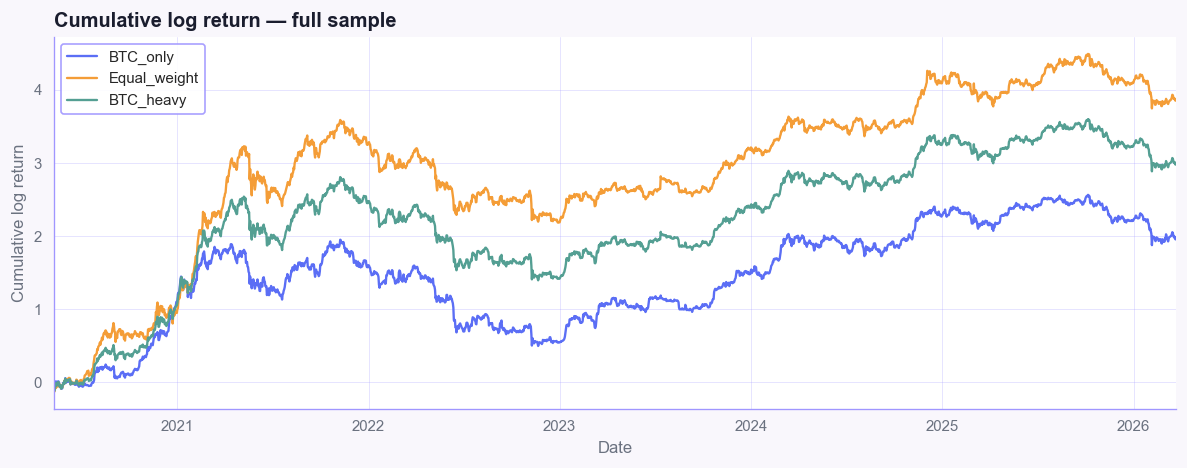

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = {"BTC_only": "#5B6EF5", "Equal_weight": "#F49D37", "BTC_heavy": "#549F93"}
for name in PORTFOLIOS:
    portfolio_log[name].cumsum().plot(ax=ax, label=name, color=colors[name], linewidth=1.4)
ax.set_title("Cumulative log return — full sample")
ax.set_ylabel("Cumulative log return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Regime-conditional portfolio metrics

For each HMM regime, slice the daily returns to the days assigned to that regime and recompute every metric. This is the heart of the analysis: if the diversification ratio is meaningfully higher in one regime than the other, the project's "regime-dependent diversification" thesis is supported.

In [9]:
regime_summaries = []
for regime, sub in portfolio_log.groupby("regime"):
    asset_sub = simple_returns.loc[sub.index]
    for name in PORTFOLIOS:
        weights = pd.Series(PORTFOLIOS[name])[ASSETS]
        row = {"regime": int(regime), "portfolio": name}
        row.update(summarize(sub[name], asset_sub, weights))
        regime_summaries.append(row)

regime_summary_df = pd.DataFrame(regime_summaries).set_index(["regime", "portfolio"])
print("Per-regime portfolio metrics:")
regime_summary_df.round(4)

Per-regime portfolio metrics:


n_days  ann_return  ann_vol  sharpe  max_drawdown  \
regime portfolio                                                         
0      BTC_only         674      0.1723   0.6547  0.2631       -1.3117   
       Equal_weight     674      1.0216   0.8450  1.2090       -1.1517   
       BTC_heavy        674      0.6114   0.7093  0.8619       -1.1681   
1      BTC_only        1470      0.2611   0.3786  0.6897       -0.5887   
       Equal_weight    1470      0.1956   0.3878  0.5043       -0.6073   
       BTC_heavy       1470      0.2345   0.3703  0.6334       -0.5777   

                     diversification_ratio  
regime portfolio                            
0      BTC_only                     1.0000  
       Equal_weight                 1.3108  
       BTC_heavy                    1.2310  
1      BTC_only                     1.0000  
       Equal_weight                 1.2065  
       BTC_heavy                    1.1389

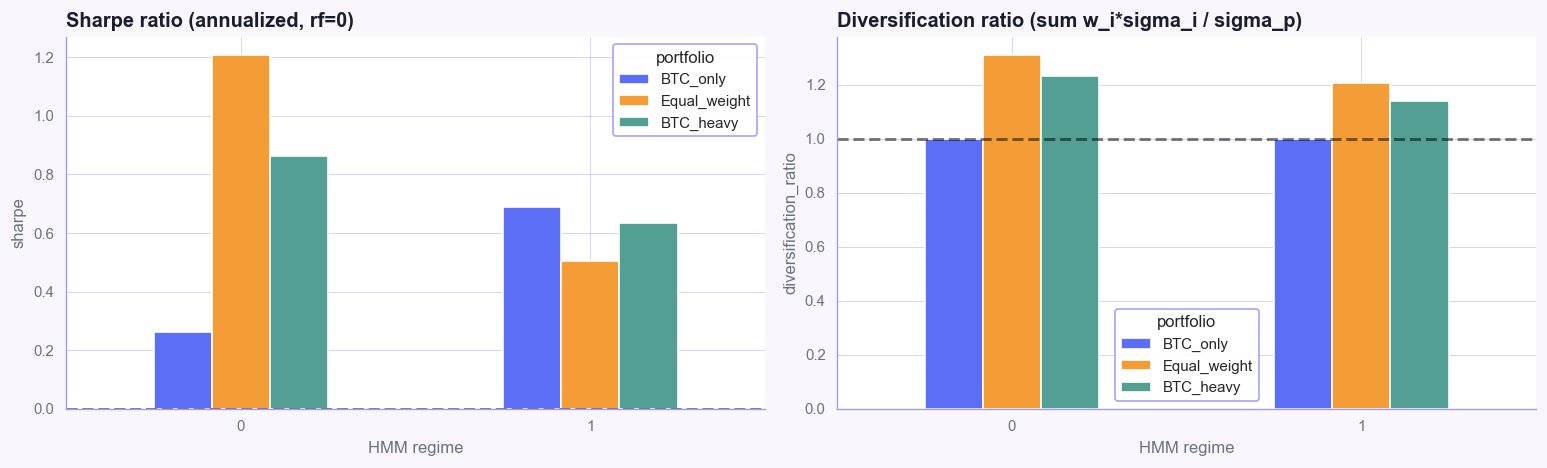

In [10]:
# Side-by-side bar charts: Sharpe and Diversification Ratio per portfolio per regime
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in zip(
    axes,
    ["sharpe", "diversification_ratio"],
    ["Sharpe ratio (annualized, rf=0)", "Diversification ratio (sum w_i*sigma_i / sigma_p)"],
):
    pivot = regime_summary_df[metric].unstack("portfolio")[list(PORTFOLIOS.keys())]
    pivot.plot(kind="bar", ax=ax, color=[colors[p] for p in PORTFOLIOS], edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("HMM regime")
    ax.set_ylabel(metric)
    ax.axhline(0 if metric == "sharpe" else 1.0, color="black", linestyle="--", alpha=0.5)
    plt.setp(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

**Reading the bars.** The dashed line on the Sharpe panel is zero (above = positive risk-adjusted return); on the diversification ratio panel it's 1.0 (above = diversification reduces portfolio vol below the weighted-average constituent vol; at 1.0 = diversification benefit has collapsed).

## Per-regime correlation matrices

The correlation structure across all six assets, computed within each regime. Lower off-diagonal values = more decoupling = more room for diversification to reduce portfolio vol.

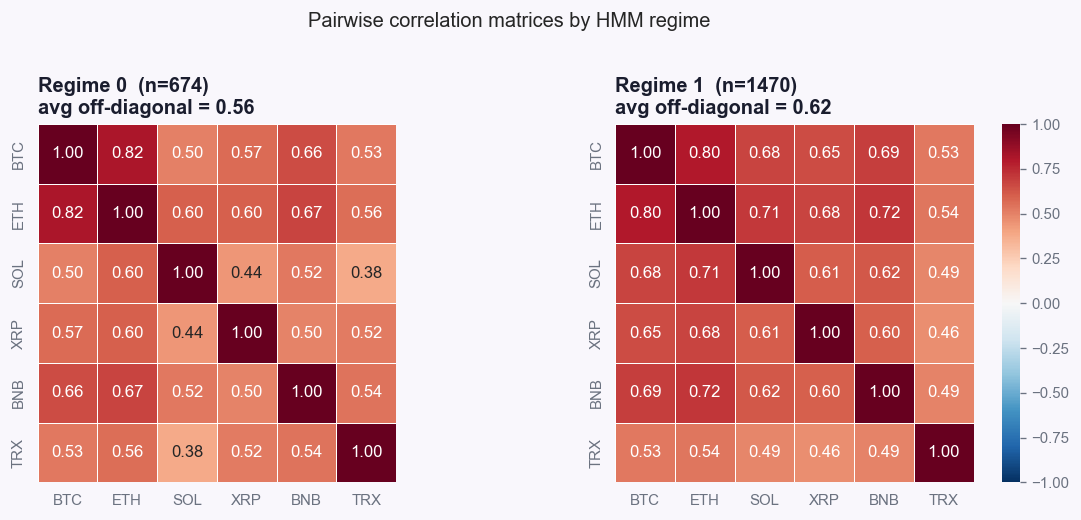

In [11]:
regimes = sorted(data["hmm_regime"].unique())
fig, axes = plt.subplots(1, len(regimes), figsize=(5 * len(regimes), 4.2))
if len(regimes) == 1:
    axes = [axes]

for ax, regime in zip(axes, regimes):
    sub = data.loc[data["hmm_regime"] == regime, ASSETS]
    corr = sub.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                ax=ax, cbar=(ax is axes[-1]), square=True, linewidths=0.5)
    avg_off = (corr.values.sum() - corr.values.trace()) / (corr.size - len(corr))
    ax.set_title(f"Regime {regime}  (n={len(sub)})\navg off-diagonal = {avg_off:.2f}")

plt.suptitle("Pairwise correlation matrices by HMM regime", y=1.02)
plt.tight_layout()
plt.show()

## Cumulative returns with regime shading

Visualizes when each regime is active over the sample. Color bands show the regime; the lines show portfolio paths.

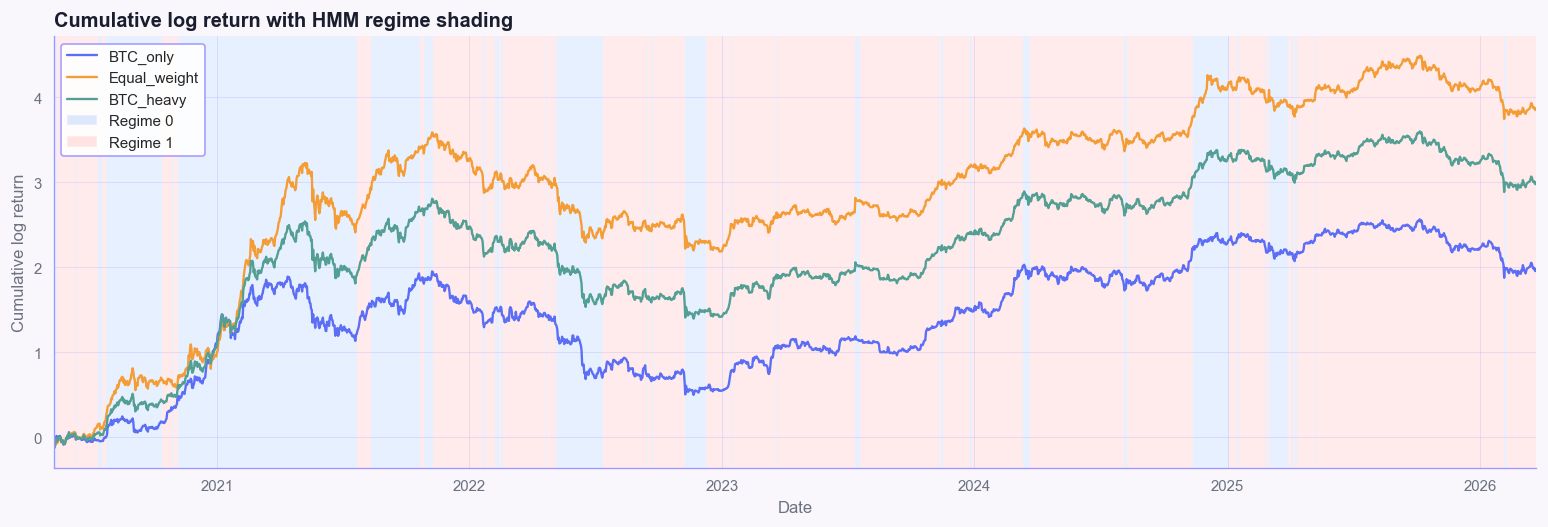

In [12]:
fig, ax = plt.subplots(figsize=(13, 4.5))

# Regime shading
regime_colors = {0: "#A0C4FF", 1: "#FFB3B3"}
prev_regime = portfolio_log["regime"].iloc[0]
span_start = portfolio_log.index[0]
for date, regime in portfolio_log["regime"].items():
    if regime != prev_regime:
        ax.axvspan(span_start, date, alpha=0.25, color=regime_colors.get(prev_regime, "grey"), linewidth=0)
        span_start = date
        prev_regime = regime
ax.axvspan(span_start, portfolio_log.index[-1], alpha=0.25, color=regime_colors.get(prev_regime, "grey"), linewidth=0)

# Portfolio cumulative log returns
for name in PORTFOLIOS:
    portfolio_log[name].cumsum().plot(ax=ax, label=name, color=colors[name], linewidth=1.4)

# Custom legend with regime swatches
from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
handles += [Patch(facecolor=regime_colors[r], alpha=0.35, label=f"Regime {r}") for r in regimes]
ax.legend(handles=handles, loc="upper left")
ax.set_title("Cumulative log return with HMM regime shading")
ax.set_ylabel("Cumulative log return")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## MLflow logging

One run per portfolio. Full-sample metrics go in as primary metrics; per-regime metrics are tagged with the regime id in the parameter name.

In [13]:
for name in PORTFOLIOS:
    with mlflow.start_run(run_name=f"portfolio_{name}"):
        weights = pd.Series(PORTFOLIOS[name])[ASSETS]
        mlflow.log_param("portfolio", name)
        for asset, w in weights.items():
            mlflow.log_param(f"weight_{asset}", float(w))
        mlflow.log_param("regime_source", "hmm_k2")
        mlflow.log_param("date_start", str(data.index.min().date()))
        mlflow.log_param("date_end",   str(data.index.max().date()))

        # Full-sample metrics
        for metric, value in full_summary[name].items():
            mlflow.log_metric(f"full_{metric}", float(value))

        # Per-regime metrics
        for regime in regimes:
            row = regime_summary_df.loc[(regime, name)]
            for metric, value in row.items():
                mlflow.log_metric(f"regime{regime}_{metric}", float(value))

print("Logged 3 MLflow runs under EXPERIMENT_DIVERSIFICATION.")

Logged 3 MLflow runs under EXPERIMENT_DIVERSIFICATION.


Limitations:
- Daily rebalancing is unrealistic (transaction costs would erode the equal-weight portfolio's returns relative to a buy-and-hold BTC baseline)
- The HMM regime label is observed at end-of-day, so this is not a live trading rule, it's a *diagnostic* of where in the past the diversification benefit was concentrated
- With more HMM states (per the K=3,4 sweep in 07) regime 0 would split further, but 07 also showed K=3 didn't add predictive value, so the extra granularity isn't necessarily warranted
- The 04/07 test window (2025-01 to 2026-03) is too short for regime-stratified portfolio analysis (regime 0 had only 36 days). Full sample is the right scope here despite the in-sample reuse with 06
- No risk-free rate baseline, Sharpe is computed with rf=0. Any positive Sharpe should be read as "vs cash returning zero".